# ML подход к транзакционному анализу пользователей криптосетей

In [9]:
# !pip install -r requirements.txt

# Этап 1. Сравнение методов на базе основного экспериментального периода

### Построение графа

In [7]:
# ============================================================
# Bitcoin transaction graph analysis — February week 2, 500k
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import hdbscan
import umap
import community as community_louvain

from node2vec import Node2Vec

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling


# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "bitcoin_weeek_2_feb.csv"   # поменяй на свое имя файла
RESULT_PREFIX = "feb_week2_500k"

RANDOM_STATE = 42


# ============================================================
# UTILS
# ============================================================

def clustering_metrics(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    if n_clusters <= 1 or mask.sum() == 0:
        return {
            "clusters": n_clusters,
            "noise": n_noise,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "clusters": n_clusters,
        "noise": n_noise,
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask])
    }


def save_cluster_sizes(labels, filename):
    sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
    sizes.to_csv(filename)
    print(sizes.head(30))
    return sizes


# ============================================================
# 1. LOAD DATA AND BUILD GRAPH
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Data shape:", df.shape)
print(df.head())

G = nx.from_pandas_edgelist(
    df,
    source="source_tx",
    target="target_tx",
    edge_attr=[
        "input_value_edge",
        "fee",
        "input_value",
        "output_value",
        "input_count",
        "output_count",
        "size",
        "virtual_size"
    ],
    create_using=nx.DiGraph()
)

print("Full graph nodes:", G.number_of_nodes())
print("Full graph edges:", G.number_of_edges())
print("Weak components:", nx.number_weakly_connected_components(G))

largest_cc = max(nx.weakly_connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()

print("LCC nodes:", G_main.number_of_nodes())
print("LCC edges:", G_main.number_of_edges())

/Users/viktoria_karpeykina/Downloads/graph_course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data shape: (500000, 12)
                                           source_tx  \
0  eb9bee67c80adb0a8d8a63404ba57857d3bf224126f097...   
1  e53a97c59fa277a83f8f173749a75bc3a30b7ca5243f58...   
2  966e7551c6fbd118484d9685295d622ab4cdf5fa5c5d2b...   
3  5e2b4664b9a897ed6e1164b2ad0616091780bcad1a23dc...   
4  643e55bf5cc9bb8779f9015d9bf915b03cf16b9a893d12...   

                                           target_tx          block_timestamp  \
0  e2cb0a1f19724185b625777ef81aab7bfc46014d0874f7...  2026-02-13 22:36:35 UTC   
1  603972baeb2133cbe91883a8d4b62012258cf0a5ec8f43...  2026-02-11 09:05:59 UTC   
2  de66b636e232cde5dedb414cda944878424e228a96ebe6...  2026-02-09 12:03:19 UTC   
3  da09d09fb2f4d2f7a7cf25a9e0a477e7fcbed05011f363...  2026-02-14 07:45:01 UTC   
4  192dac8f53cae99114a02b43fdac21113b951d27572e9f...  2026-02-14 09:43:44 UTC   

      tx_date  input_count  output_count  input_value  output_value  fee  \
0  2026-02-13            1             2        25061         25044   17   

### 1. Baseline подход

In [6]:
# ============================================================
# 2. CLASSICAL GRAPH METRICS BASELINE
# ============================================================

nodes_main = list(G_main.nodes())

degree = dict(G_main.degree())
in_degree = dict(G_main.in_degree())
out_degree = dict(G_main.out_degree())
pagerank = nx.pagerank(G_main, alpha=0.85, max_iter=100)

G_undirected = G_main.to_undirected()
clustering = nx.clustering(G_undirected)

betweenness = nx.betweenness_centrality(
    G_main,
    k=min(1000, G_main.number_of_nodes()),
    seed=RANDOM_STATE
)

baseline_features_df = pd.DataFrame({
    "node": nodes_main,
    "degree": [degree[n] for n in nodes_main],
    "in_degree": [in_degree[n] for n in nodes_main],
    "out_degree": [out_degree[n] for n in nodes_main],
    "pagerank": [pagerank[n] for n in nodes_main],
    "clustering": [clustering[n] for n in nodes_main],
    "betweenness": [betweenness[n] for n in nodes_main],
})

baseline_feature_cols = [
    "degree",
    "in_degree",
    "out_degree",
    "pagerank",
    "clustering",
    "betweenness"
]

X_baseline = baseline_features_df[baseline_feature_cols].copy()

for col in ["degree", "in_degree", "out_degree", "pagerank", "betweenness"]:
    X_baseline[col] = np.log1p(X_baseline[col])

scaler = StandardScaler()
X_baseline_scaled = scaler.fit_transform(X_baseline)

baseline_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    core_dist_n_jobs=1
)

baseline_labels = baseline_clusterer.fit_predict(X_baseline_scaled)

baseline_features_df["baseline_cluster"] = baseline_labels
baseline_features_df.to_csv(f"{RESULT_PREFIX}_baseline_node_features.csv", index=False)

baseline_metrics = clustering_metrics(X_baseline_scaled, baseline_labels)

print("Baseline metrics:", baseline_metrics)
save_cluster_sizes(
    baseline_labels,
    f"{RESULT_PREFIX}_baseline_cluster_sizes.csv"
)

Baseline metrics: {'clusters': 101, 'noise': 2096, 'silhouette': 0.9718465950651016, 'davies_bouldin': 0.5301429468437127, 'calinski_harabasz': 145881.86349333203}
 3     92325
 5      9505
 60     3160
 8      2881
 20     2627
-1      2096
 51     1579
 9      1395
 64     1188
 74      938
 10      801
 73      720
 54      675
 62      642
 27      627
 72      541
 11      492
 52      468
 55      435
 86      410
 13      391
 85      385
 63      366
 1       360
 88      351
 99      346
 14      299
 2       290
 57      286
 34      271
Name: count, dtype: int64


3      92325
5       9505
60      3160
8       2881
20      2627
       ...  
49        55
25        55
59        54
35        51
100       50
Name: count, Length: 102, dtype: int64

### 2. Node2Vec

In [7]:
# ============================================================
# 3. NODE2VEC
# ============================================================

node2vec = Node2Vec(
    G_main,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    workers=1
)

node2vec_model = node2vec.fit(
    window=10,
    min_count=1
)

node2vec_embeddings = np.array([
    node2vec_model.wv[node]
    for node in nodes_main
])

print("Node2Vec embeddings shape:", node2vec_embeddings.shape)

node2vec_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    core_dist_n_jobs=1
)

node2vec_labels = node2vec_clusterer.fit_predict(node2vec_embeddings)

node2vec_result_df = pd.DataFrame({
    "node": nodes_main,
    "node2vec_cluster": node2vec_labels
})

node2vec_result_df.to_csv(f"{RESULT_PREFIX}_node2vec_clusters.csv", index=False)

node2vec_metrics = clustering_metrics(node2vec_embeddings, node2vec_labels)

print("Node2Vec metrics:", node2vec_metrics)
save_cluster_sizes(
    node2vec_labels,
    f"{RESULT_PREFIX}_node2vec_cluster_sizes.csv"
)




Generating walks (CPU: 1): 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Node2Vec embeddings shape: (134463, 64)
Node2Vec metrics: {'clusters': 480, 'noise': 63258, 'silhouette': 0.6762575507164001, 'davies_bouldin': 0.7437091425328018, 'calinski_harabasz': 2062.433139557949}
-1      63258
 478     6294
 460     1739
 476     1734
 419      971
 373      913
 455      878
 438      800
 452      637
 472      620
 458      570
 195      555
 303      513
 426      457
 24       449
 20       446
 479      442
 359      428
 79       427
 100      399
 272      380
 290      367
 386      354
 56       351
 291      342
 294      339
 113      331
 369      324
 23       294
 327      291
Name: count, dtype: int64


-1      63258
 478     6294
 460     1739
 476     1734
 419      971
        ...  
 251       50
 21        50
 123       50
 352       50
 43        50
Name: count, Length: 481, dtype: int64

Визуализация кластеризации Node2Vec

/Users/viktoria_karpeykina/Downloads/graph_course/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


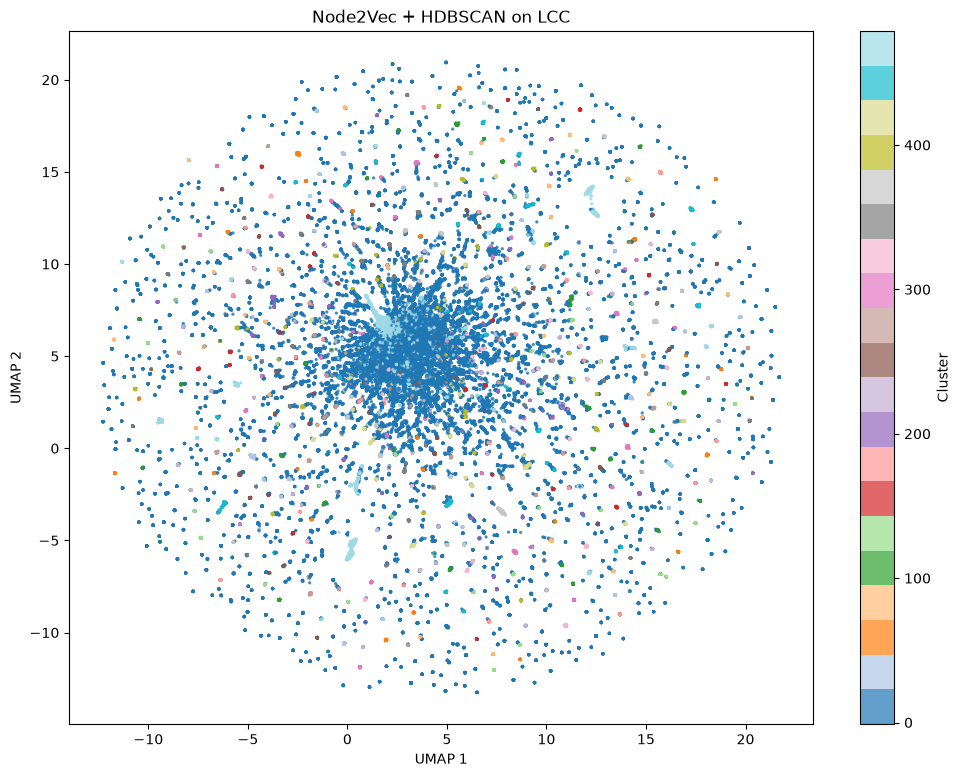

In [8]:
# ============================================================
# 4. NODE2VEC UMAP
# ============================================================

node2vec_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

node2vec_2d = node2vec_umap.fit_transform(node2vec_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    node2vec_2d[:, 0],
    node2vec_2d[:, 1],
    c=node2vec_labels,
    s=2,
    cmap="tab20",
    alpha=0.7
)
plt.title("Node2Vec + HDBSCAN on LCC")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Cluster")
plt.savefig(f"{RESULT_PREFIX}_node2vec_umap.png", dpi=300, bbox_inches="tight")
plt.show()




### 3. Louvain

Louvain metrics: {'clusters': 171, 'noise': 0, 'silhouette': -0.09143923968076706, 'davies_bouldin': 4.558248624802846, 'calinski_harabasz': 116.99458541771851, 'modularity': 0.9243631070749325}
0      5102
31     3698
48     3332
56     3295
52     3196
30     3062
29     3016
38     2413
37     2401
75     2310
14     2268
51     2263
3      2215
89     2215
26     2173
35     2100
70     2006
55     1929
34     1847
7      1796
27     1722
42     1653
122    1608
81     1587
117    1540
93     1534
47     1520
73     1476
33     1386
57     1383
Name: count, dtype: int64


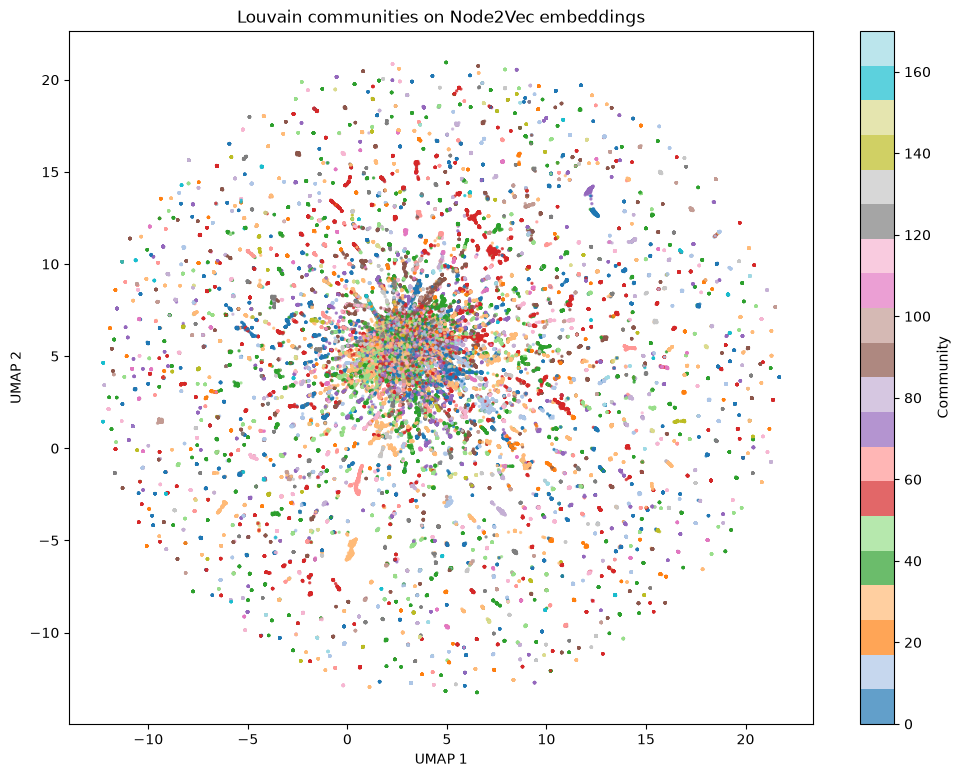

In [9]:
# ============================================================
# 5. LOUVAIN
# ============================================================

G_louvain = G_main.to_undirected()

louvain_partition = community_louvain.best_partition(
    G_louvain,
    random_state=RANDOM_STATE
)

louvain_labels = np.array([
    louvain_partition[node]
    for node in nodes_main
])

louvain_modularity = community_louvain.modularity(
    louvain_partition,
    G_louvain
)

louvain_result_df = pd.DataFrame({
    "node": nodes_main,
    "louvain_cluster": louvain_labels
})

louvain_result_df.to_csv(f"{RESULT_PREFIX}_louvain_clusters.csv", index=False)

louvain_metrics_on_node2vec = {
    "clusters": len(set(louvain_labels)),
    "noise": 0,
    "silhouette": silhouette_score(node2vec_embeddings, louvain_labels),
    "davies_bouldin": davies_bouldin_score(node2vec_embeddings, louvain_labels),
    "calinski_harabasz": calinski_harabasz_score(node2vec_embeddings, louvain_labels),
    "modularity": louvain_modularity
}

print("Louvain metrics:", louvain_metrics_on_node2vec)
save_cluster_sizes(
    louvain_labels,
    f"{RESULT_PREFIX}_louvain_cluster_sizes.csv"
)

plt.figure(figsize=(12, 9))
plt.scatter(
    node2vec_2d[:, 0],
    node2vec_2d[:, 1],
    c=louvain_labels,
    s=2,
    cmap="tab20",
    alpha=0.7
)
plt.title("Louvain communities on Node2Vec embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Community")
plt.savefig(f"{RESULT_PREFIX}_louvain_on_node2vec_umap.png", dpi=300, bbox_inches="tight")
plt.show()




### 4. GraphSAGE with Features

In [10]:
# ============================================================
# 6. GRAPHSAGE WITH FEATURES
# ============================================================

node_to_idx = {node: i for i, node in enumerate(nodes_main)}

edges = [
    (node_to_idx[u], node_to_idx[v])
    for u, v in G_main.edges()
]

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

graphsage_X = pd.DataFrame({
    "degree": [degree[n] for n in nodes_main],
    "in_degree": [in_degree[n] for n in nodes_main],
    "out_degree": [out_degree[n] for n in nodes_main],
    "pagerank": [pagerank[n] for n in nodes_main],
})

for col in graphsage_X.columns:
    graphsage_X[col] = np.log1p(graphsage_X[col])

graphsage_X_scaled = StandardScaler().fit_transform(graphsage_X)
x = torch.tensor(graphsage_X_scaled, dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

print(data)


class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


def link_prediction_loss(z, pos_edge_index, num_nodes):
    neg_edge_index = negative_sampling(
        edge_index=pos_edge_index,
        num_nodes=num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    pos_score = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=1)
    neg_score = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=1)

    pos_loss = F.binary_cross_entropy_with_logits(
        pos_score,
        torch.ones_like(pos_score)
    )

    neg_loss = F.binary_cross_entropy_with_logits(
        neg_score,
        torch.zeros_like(neg_score)
    )

    return pos_loss + neg_loss


graphsage_model = GraphSAGEEncoder(
    in_channels=x.shape[1],
    hidden_channels=64,
    out_channels=64
)

optimizer = torch.optim.Adam(
    graphsage_model.parameters(),
    lr=0.01,
    weight_decay=1e-5
)

epochs = 100

for epoch in range(1, epochs + 1):
    graphsage_model.train()
    optimizer.zero_grad()

    z = graphsage_model(data.x, data.edge_index)

    loss = link_prediction_loss(
        z,
        data.edge_index,
        num_nodes=data.num_nodes
    )

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"GraphSAGE epoch {epoch:03d}, loss: {loss.item():.4f}")

graphsage_model.eval()

with torch.no_grad():
    z = graphsage_model(data.x, data.edge_index)

graphsage_embeddings = z.cpu().numpy()

Data(x=[134463, 4], edge_index=[2, 151580])
GraphSAGE epoch 010, loss: 1.0440
GraphSAGE epoch 020, loss: 0.9689
GraphSAGE epoch 030, loss: 0.9441
GraphSAGE epoch 040, loss: 0.9352
GraphSAGE epoch 050, loss: 0.9236
GraphSAGE epoch 060, loss: 0.9222
GraphSAGE epoch 070, loss: 0.9228
GraphSAGE epoch 080, loss: 0.9148
GraphSAGE epoch 090, loss: 0.9129
GraphSAGE epoch 100, loss: 0.9188


In [11]:
graphsage_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    core_dist_n_jobs=1
)

graphsage_labels = graphsage_clusterer.fit_predict(graphsage_embeddings)

graphsage_result_df = pd.DataFrame({
    "node": nodes_main,
    "graphsage_cluster": graphsage_labels
})

graphsage_result_df.to_csv(f"{RESULT_PREFIX}_graphsage_clusters.csv", index=False)

graphsage_metrics = clustering_metrics(graphsage_embeddings, graphsage_labels)

print("GraphSAGE metrics:", graphsage_metrics)
save_cluster_sizes(
    graphsage_labels,
    f"{RESULT_PREFIX}_graphsage_cluster_sizes.csv"
)


GraphSAGE metrics: {'clusters': 89, 'noise': 4356, 'silhouette': 0.974122941493988, 'davies_bouldin': 0.7588385370277492, 'calinski_harabasz': 103288.53182940048}
 8     92325
 28     9863
-1      4356
 3      3160
 63     2971
 14     2565
 22     1560
 23     1465
 34     1139
 35      910
 24      854
 53      843
 36      712
 37      669
 7       633
 80      577
 25      521
 38      424
 26      411
 19      327
 78      310
 11      308
 39      282
 33      261
 79      258
 29      244
 45      240
 59      229
 9       208
 72      207
Name: count, dtype: int64


 8     92325
 28     9863
-1      4356
 3      3160
 63     2971
       ...  
 56       53
 48       53
 0        53
 70       52
 71       52
Name: count, Length: 90, dtype: int64

### 5. Structural GraphSAGE

In [12]:
# ============================================================
# 7. STRUCTURAL GRAPHSAGE
# ============================================================

x_struct = torch.ones((len(nodes_main), 1), dtype=torch.float)

data_struct = Data(
    x=x_struct,
    edge_index=edge_index
)


class StructuralGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


struct_model = StructuralGraphSAGE(
    in_channels=1,
    hidden_channels=64,
    out_channels=64
)

struct_optimizer = torch.optim.Adam(
    struct_model.parameters(),
    lr=0.01,
    weight_decay=1e-5
)

for epoch in range(1, epochs + 1):
    struct_model.train()
    struct_optimizer.zero_grad()

    z = struct_model(data_struct.x, data_struct.edge_index)

    loss = link_prediction_loss(
        z,
        data_struct.edge_index,
        num_nodes=data_struct.num_nodes
    )

    loss.backward()
    struct_optimizer.step()

    if epoch % 10 == 0:
        print(f"Structural GraphSAGE epoch {epoch:03d}, loss: {loss.item():.4f}")

struct_model.eval()

with torch.no_grad():
    z = struct_model(data_struct.x, data_struct.edge_index)

struct_embeddings = z.cpu().numpy()



Structural GraphSAGE epoch 010, loss: 1.6549
Structural GraphSAGE epoch 020, loss: 1.3774
Structural GraphSAGE epoch 030, loss: 1.3440
Structural GraphSAGE epoch 040, loss: 1.3301
Structural GraphSAGE epoch 050, loss: 1.3275
Structural GraphSAGE epoch 060, loss: 1.3266
Structural GraphSAGE epoch 070, loss: 1.3261
Structural GraphSAGE epoch 080, loss: 1.3251
Structural GraphSAGE epoch 090, loss: 1.3246
Structural GraphSAGE epoch 100, loss: 1.3262


In [13]:
struct_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    core_dist_n_jobs=1
)

struct_labels = struct_clusterer.fit_predict(struct_embeddings)

struct_result_df = pd.DataFrame({
    "node": nodes_main,
    "structural_graphsage_cluster": struct_labels
})

struct_result_df.to_csv(f"{RESULT_PREFIX}_structural_graphsage_clusters.csv", index=False)

struct_metrics = clustering_metrics(struct_embeddings, struct_labels)

print("Structural GraphSAGE metrics:", struct_metrics)
save_cluster_sizes(
    struct_labels,
    f"{RESULT_PREFIX}_structural_graphsage_cluster_sizes.csv"
)

Structural GraphSAGE metrics: {'clusters': 31, 'noise': 418, 'silhouette': 0.9486293792724609, 'davies_bouldin': 2.232314911346727, 'calinski_harabasz': 1140528632.463343}
 0     108969
 22     18056
 1       1565
 18      1251
 2        526
 21       455
 29       441
-1        418
 14       331
 16       271
 3        182
 5        180
 12       165
 26       143
 6        143
 7        131
 9        113
 28       111
 30       100
 4         85
 17        82
 13        81
 15        81
 24        78
 27        78
 20        70
 25        67
 19        62
 8         61
 10        57
Name: count, dtype: int64


 0     108969
 22     18056
 1       1565
 18      1251
 2        526
 21       455
 29       441
-1        418
 14       331
 16       271
 3        182
 5        180
 12       165
 26       143
 6        143
 7        131
 9        113
 28       111
 30       100
 4         85
 17        82
 13        81
 15        81
 24        78
 27        78
 20        70
 25        67
 19        62
 8         61
 10        57
 11        57
 23        53
Name: count, dtype: int64

### Сравнение методов

In [14]:
# ============================================================
# 8. FINAL COMPARISON TABLE
# ============================================================

comparison_table = pd.DataFrame([
    {
        "method": "Classical graph metrics",
        "graph": "LCC",
        **baseline_metrics,
        "modularity": np.nan
    },
    {
        "method": "Node2Vec + HDBSCAN",
        "graph": "LCC",
        **node2vec_metrics,
        "modularity": np.nan
    },
    {
        "method": "Louvain",
        "graph": "LCC",
        **{
            "clusters": louvain_metrics_on_node2vec["clusters"],
            "noise": louvain_metrics_on_node2vec["noise"],
            "silhouette": louvain_metrics_on_node2vec["silhouette"],
            "davies_bouldin": louvain_metrics_on_node2vec["davies_bouldin"],
            "calinski_harabasz": louvain_metrics_on_node2vec["calinski_harabasz"],
            "modularity": louvain_metrics_on_node2vec["modularity"]
        }
    },
    {
        "method": "GraphSAGE + features",
        "graph": "LCC",
        **graphsage_metrics,
        "modularity": np.nan
    },
    {
        "method": "Structural GraphSAGE",
        "graph": "LCC",
        **struct_metrics,
        "modularity": np.nan
    }
])

comparison_table.to_csv(
    f"{RESULT_PREFIX}_final_methods_comparison.csv",
    index=False
)

display(comparison_table)

print("Saved final table:")
print(f"{RESULT_PREFIX}_final_methods_comparison.csv")

,method,graph,clusters,noise,silhouette,davies_bouldin,calinski_harabasz,modularity
0,Classical graph metrics,LCC,101,2096,0.971847,0.530143,1.458819e+05,NaN
1,Node2Vec + HDBSCAN,LCC,480,63258,0.676258,0.743709,2.062433e+03,NaN
2,Louvain,LCC,171,0,-0.091439,4.558249,1.169946e+02,0.924363
3,GraphSAGE + features,LCC,89,4356,0.974123,0.758839,1.032885e+05,NaN
4,Structural GraphSAGE,LCC,31,418,0.948629,2.232315,1.140529e+09,NaN


Saved final table:
feb_week2_500k_final_methods_comparison.csv


# Этап 2. Проверка устойчивости на других временных периодах

### Конфигурации моделей

In [22]:
# =========================
# CONFIG
# =========================

WEEK_FILES = {
    "jan_week": "data/bitcoin_week_2_jan.csv",
    "mar_week": "data/bitcoin_week_2_mar.csv",
    "apr_week": "data/bitcoin_week_2_apr.csv",
    "may_week": "data/bitcoin_week_2_may.csv",
}

RESULTS_DIR = "monthly_week_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42

In [23]:
# =========================
# UTILS
# =========================

def clustering_metrics(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    if n_clusters <= 1 or mask.sum() == 0:
        return {
            "clusters": n_clusters,
            "noise": n_noise,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "clusters": n_clusters,
        "noise": n_noise,
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask])
    }


def process_week(label, csv_path):
    print("=" * 80)
    print(f"Processing: {label}")
    print("=" * 80)

    # =========================
    # 1. Load data
    # =========================

    df = pd.read_csv(csv_path)

    print("Data shape:", df.shape)

    G = nx.from_pandas_edgelist(
        df,
        source="source_tx",
        target="target_tx",
        edge_attr=[
            "input_value_edge",
            "fee",
            "input_value",
            "output_value",
            "input_count",
            "output_count",
            "size",
            "virtual_size"
        ],
        create_using=nx.DiGraph()
    )

    full_nodes = G.number_of_nodes()
    full_edges = G.number_of_edges()
    weak_components = nx.number_weakly_connected_components(G)

    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G_main = G.subgraph(largest_cc).copy()

    lcc_nodes = G_main.number_of_nodes()
    lcc_edges = G_main.number_of_edges()

    print("Full graph nodes:", full_nodes)
    print("Full graph edges:", full_edges)
    print("Weak components:", weak_components)
    print("LCC nodes:", lcc_nodes)
    print("LCC edges:", lcc_edges)

    nodes_main = list(G_main.nodes())

    # =========================
    # 2. Louvain
    # =========================

    print("Running Louvain...")

    G_louvain = G_main.to_undirected()

    louvain_partition = community_louvain.best_partition(
        G_louvain,
        random_state=RANDOM_STATE
    )

    louvain_labels = np.array([
        louvain_partition[node]
        for node in nodes_main
    ])

    louvain_modularity = community_louvain.modularity(
        louvain_partition,
        G_louvain
    )

    louvain_clusters = len(set(louvain_labels))

    louvain_result_df = pd.DataFrame({
        "node": nodes_main,
        "louvain_cluster": louvain_labels
    })

    louvain_result_df.to_csv(
        f"{RESULTS_DIR}/{label}_louvain_clusters.csv",
        index=False
    )

    pd.Series(louvain_labels).value_counts().sort_values(ascending=False).to_csv(
        f"{RESULTS_DIR}/{label}_louvain_cluster_sizes.csv"
    )

    print("Louvain clusters:", louvain_clusters)
    print("Louvain modularity:", louvain_modularity)

    # =========================
    # 3. Node2Vec
    # =========================

    print("Running Node2Vec...")

    node2vec = Node2Vec(
        G_main,
        dimensions=64,
        walk_length=20,
        num_walks=50,
        workers=1
    )

    node2vec_model = node2vec.fit(
        window=10,
        min_count=1
    )

    node2vec_embeddings = np.array([
        node2vec_model.wv[node]
        for node in nodes_main
    ])

    np.save(
        f"{RESULTS_DIR}/{label}_node2vec_embeddings.npy",
        node2vec_embeddings
    )

    # =========================
    # 4. HDBSCAN
    # =========================

    print("Running HDBSCAN on Node2Vec embeddings...")

    node2vec_clusterer = hdbscan.HDBSCAN(
        min_cluster_size=50,
        min_samples=10,
        core_dist_n_jobs=1
    )

    node2vec_labels = node2vec_clusterer.fit_predict(
        node2vec_embeddings
    )

    node2vec_metrics = clustering_metrics(
        node2vec_embeddings,
        node2vec_labels
    )

    node2vec_result_df = pd.DataFrame({
        "node": nodes_main,
        "node2vec_cluster": node2vec_labels
    })

    node2vec_result_df.to_csv(
        f"{RESULTS_DIR}/{label}_node2vec_clusters.csv",
        index=False
    )

    pd.Series(node2vec_labels).value_counts().sort_values(ascending=False).to_csv(
        f"{RESULTS_DIR}/{label}_node2vec_cluster_sizes.csv"
    )

    print("Node2Vec metrics:", node2vec_metrics)

    # =========================
    # 5. Louvain metrics in Node2Vec embedding space
    # =========================

    louvain_embedding_metrics = {
        "silhouette": silhouette_score(node2vec_embeddings, louvain_labels),
        "davies_bouldin": davies_bouldin_score(node2vec_embeddings, louvain_labels),
        "calinski_harabasz": calinski_harabasz_score(node2vec_embeddings, louvain_labels)
    }

    # =========================
    # 6. Summary
    # =========================

    summary_rows = []

    summary_rows.append({
        "week": label,
        "method": "Louvain",
        "full_nodes": full_nodes,
        "full_edges": full_edges,
        "weak_components": weak_components,
        "lcc_nodes": lcc_nodes,
        "lcc_edges": lcc_edges,
        "clusters": louvain_clusters,
        "noise": 0,
        "silhouette": louvain_embedding_metrics["silhouette"],
        "davies_bouldin": louvain_embedding_metrics["davies_bouldin"],
        "calinski_harabasz": louvain_embedding_metrics["calinski_harabasz"],
        "modularity": louvain_modularity
    })

    summary_rows.append({
        "week": label,
        "method": "Node2Vec + HDBSCAN",
        "full_nodes": full_nodes,
        "full_edges": full_edges,
        "weak_components": weak_components,
        "lcc_nodes": lcc_nodes,
        "lcc_edges": lcc_edges,
        "clusters": node2vec_metrics["clusters"],
        "noise": node2vec_metrics["noise"],
        "silhouette": node2vec_metrics["silhouette"],
        "davies_bouldin": node2vec_metrics["davies_bouldin"],
        "calinski_harabasz": node2vec_metrics["calinski_harabasz"],
        "modularity": np.nan
    })

    summary_df = pd.DataFrame(summary_rows)

    summary_df.to_csv(
        f"{RESULTS_DIR}/{label}_summary.csv",
        index=False
    )

    return summary_df

### Запуск

In [24]:
# =========================
# RUN ALL WEEKS
# =========================

all_summaries = []

for label, csv_path in WEEK_FILES.items():
    summary = process_week(label, csv_path)
    all_summaries.append(summary)

monthly_comparison = pd.concat(
    all_summaries,
    ignore_index=True
)

monthly_comparison.to_csv(
    f"{RESULTS_DIR}/monthly_week_comparison.csv",
    index=False
)

display(monthly_comparison)

Processing: jan_week
Data shape: (500000, 12)
Full graph nodes: 590667
Full graph edges: 475219
Weak components: 138481
LCC nodes: 150256
LCC edges: 172581
Running Louvain...
Louvain clusters: 214
Louvain modularity: 0.9153508171660598
Running Node2Vec...


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:29<00:00,  1.68it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Running HDBSCAN on Node2Vec embeddings...
Node2Vec metrics: {'clusters': 558, 'noise': 69539, 'silhouette': 0.7006340622901917, 'davies_bouldin': 0.7951594252308652, 'calinski_harabasz': 2026.9952963018934}
Processing: mar_week
Data shape: (500000, 12)
Full graph nodes: 615625
Full graph edges: 473701
Weak components: 166875
LCC nodes: 145340
LCC edges: 169325
Running Louvain...
Louvain clusters: 190
Louvain modularity: 0.9069426947815596
Running Node2Vec...


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:29<00:00,  1.70it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Running HDBSCAN on Node2Vec embeddings...
Node2Vec metrics: {'clusters': 483, 'noise': 70788, 'silhouette': 0.6709787845611572, 'davies_bouldin': 0.9023689350532594, 'calinski_harabasz': 2065.9482966488335}
Processing: apr_week
Data shape: (500000, 12)
Full graph nodes: 707816
Full graph edges: 480076
Weak components: 246182
LCC nodes: 126346
LCC edges: 144488
Running Louvain...
Louvain clusters: 193
Louvain modularity: 0.9205009598916083
Running Node2Vec...


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:29<00:00,  1.71it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Running HDBSCAN on Node2Vec embeddings...
Node2Vec metrics: {'clusters': 453, 'noise': 62217, 'silhouette': 0.697439432144165, 'davies_bouldin': 0.7433326004627652, 'calinski_harabasz': 1789.82286581218}
Processing: may_week
Data shape: (500000, 12)
Full graph nodes: 723018
Full graph edges: 480459
Weak components: 259171
LCC nodes: 118002
LCC edges: 134344
Running Louvain...
Louvain clusters: 186
Louvain modularity: 0.9204301996550068
Running Node2Vec...


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Running HDBSCAN on Node2Vec embeddings...
Node2Vec metrics: {'clusters': 397, 'noise': 58473, 'silhouette': 0.6808131337165833, 'davies_bouldin': 0.6710372291489711, 'calinski_harabasz': 1931.5554496682478}


,week,method,full_nodes,full_edges,weak_components,lcc_nodes,lcc_edges,clusters,noise,silhouette,davies_bouldin,calinski_harabasz,modularity
0,jan_week,Louvain,590667,475219,138481,150256,172581,214,0,-0.146352,4.142835,91.369142,0.915351
1,jan_week,Node2Vec + HDBSCAN,590667,475219,138481,150256,172581,558,69539,0.700634,0.795159,2026.995296,NaN
2,mar_week,Louvain,615625,473701,166875,145340,169325,190,0,-0.163959,4.186972,104.900282,0.906943
3,mar_week,Node2Vec + HDBSCAN,615625,473701,166875,145340,169325,483,70788,0.670979,0.902369,2065.948297,NaN
4,apr_week,Louvain,707816,480076,246182,126346,144488,193,0,-0.154045,4.143229,90.605776,0.920501
5,apr_week,Node2Vec + HDBSCAN,707816,480076,246182,126346,144488,453,62217,0.697439,0.743333,1789.822866,NaN
6,may_week,Louvain,723018,480459,259171,118002,134344,186,0,-0.128425,3.875945,90.708217,0.920430
7,may_week,Node2Vec + HDBSCAN,723018,480459,259171,118002,134344,397,58473,0.680813,0.671037,1931.555450,NaN


### Сравнение с базовым периодом

In [ ]:
# ==========================================
# February Louvain + Node2Vec results
# ==========================================

feb_rows = comparison_table[
    comparison_table["method"].isin([
        "Louvain",
        "Node2Vec + HDBSCAN"
    ])
].copy()

# информация о февральском графе
feb_rows["week"] = "feb_week"

feb_rows["full_nodes"] = G.number_of_nodes()
feb_rows["full_edges"] = G.number_of_edges()
feb_rows["weak_components"] = nx.number_weakly_connected_components(G)

feb_rows["lcc_nodes"] = G_main.number_of_nodes()
feb_rows["lcc_edges"] = G_main.number_of_edges()

# порядок столбцов как в monthly_comparison
feb_rows = feb_rows[
    [
        "week",
        "method",
        "full_nodes",
        "full_edges",
        "weak_components",
        "lcc_nodes",
        "lcc_edges",
        "clusters",
        "noise",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
        "modularity"
    ]
]

# объединяем
monthly_comparison_with_feb = pd.concat(
    [monthly_comparison, feb_rows],
    ignore_index=True
)

# сортируем месяцы
month_order = {
    "jan_week": 1,
    "feb_week": 2,
    "mar_week": 3,
    "apr_week": 4,
    "may_week": 5
}

monthly_comparison_with_feb = (
    monthly_comparison_with_feb
    .assign(order=lambda x: x["week"].map(month_order))
    .sort_values(["order", "method"])
    .drop(columns="order")
    .reset_index(drop=True)
)

display(monthly_comparison_with_feb)

monthly_comparison_with_feb.to_csv(
    "monthly_comparison_jan_may_2026.csv",
    index=False
)

,week,method,full_nodes,full_edges,weak_components,lcc_nodes,lcc_edges,clusters,noise,silhouette,davies_bouldin,calinski_harabasz,modularity
0,jan_week,Louvain,590667,475219,138481,150256,172581,214,0,-0.146352,4.142835,91.369142,0.915351
1,jan_week,Node2Vec + HDBSCAN,590667,475219,138481,150256,172581,558,69539,0.700634,0.795159,2026.995296,NaN
2,feb_week,Louvain,652933,482358,188566,134463,151580,171,0,-0.091439,4.558249,116.994585,0.924363
3,feb_week,Node2Vec + HDBSCAN,652933,482358,188566,134463,151580,480,63258,0.676258,0.743709,2062.433140,NaN
4,mar_week,Louvain,615625,473701,166875,145340,169325,190,0,-0.163959,4.186972,104.900282,0.906943
5,mar_week,Node2Vec + HDBSCAN,615625,473701,166875,145340,169325,483,70788,0.670979,0.902369,2065.948297,NaN
6,apr_week,Louvain,707816,480076,246182,126346,144488,193,0,-0.154045,4.143229,90.605776,0.920501
7,apr_week,Node2Vec + HDBSCAN,707816,480076,246182,126346,144488,453,62217,0.697439,0.743333,1789.822866,NaN
8,may_week,Louvain,723018,480459,259171,118002,134344,186,0,-0.128425,3.875945,90.708217,0.920430
9,may_week,Node2Vec + HDBSCAN,723018,480459,259171,118002,134344,397,58473,0.680813,0.671037,1931.555450,NaN


# Этап 3. Графики

### Динамика

In [27]:
# берем итоговую таблицу
df = monthly_comparison_with_feb.copy()

month_order = {
    "jan_week": 1,
    "feb_week": 2,
    "mar_week": 3,
    "apr_week": 4,
    "may_week": 5
}

month_names = {
    "jan_week": "Jan",
    "feb_week": "Feb",
    "mar_week": "Mar",
    "apr_week": "Apr",
    "may_week": "May"
}

df["month_num"] = df["week"].map(month_order)
df["month"] = df["week"].map(month_names)

df = df.sort_values("month_num")

#### Динамика количества кластеров

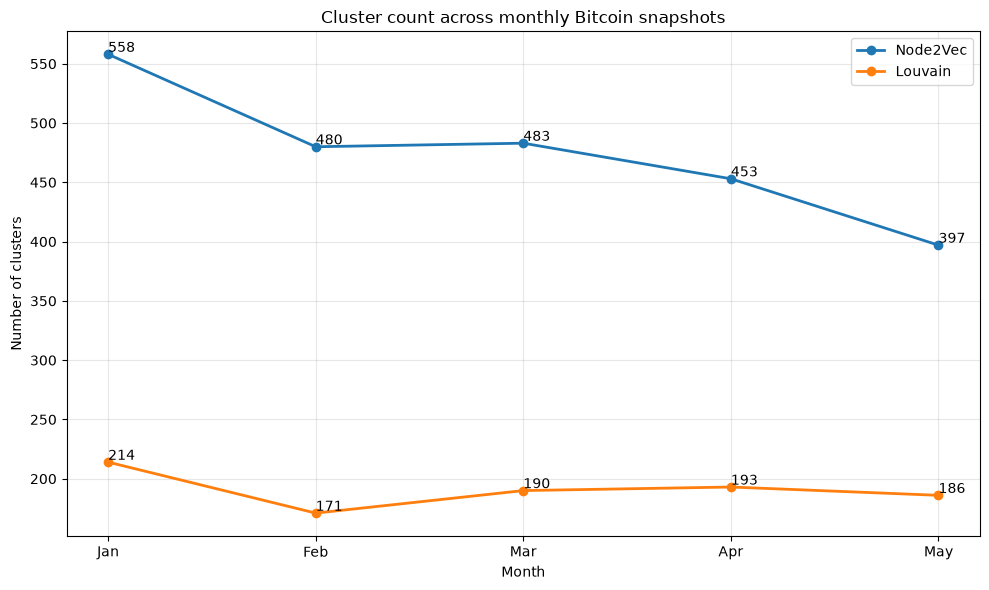

In [44]:
node2vec_df = df[df["method"] == "Node2Vec + HDBSCAN"]
louvain_df = df[df["method"] == "Louvain"]

plt.figure(figsize=(10,6))

plt.plot(
    node2vec_df["month"],
    node2vec_df["clusters"],
    marker="o",
    linewidth=2,
    label="Node2Vec"
)

plt.plot(
    louvain_df["month"],
    louvain_df["clusters"],
    marker="o",
    linewidth=2,
    label="Louvain"
)

for x, y in zip(node2vec_df["month"], node2vec_df["clusters"]):
    plt.annotate(str(y), (x, y+2))

for x, y in zip(louvain_df["month"], louvain_df["clusters"]):
    plt.annotate(str(y), (x, y+2))

plt.ylabel("Number of clusters")
plt.xlabel("Month")
plt.title("Cluster count across monthly Bitcoin snapshots")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### Динамика модульности

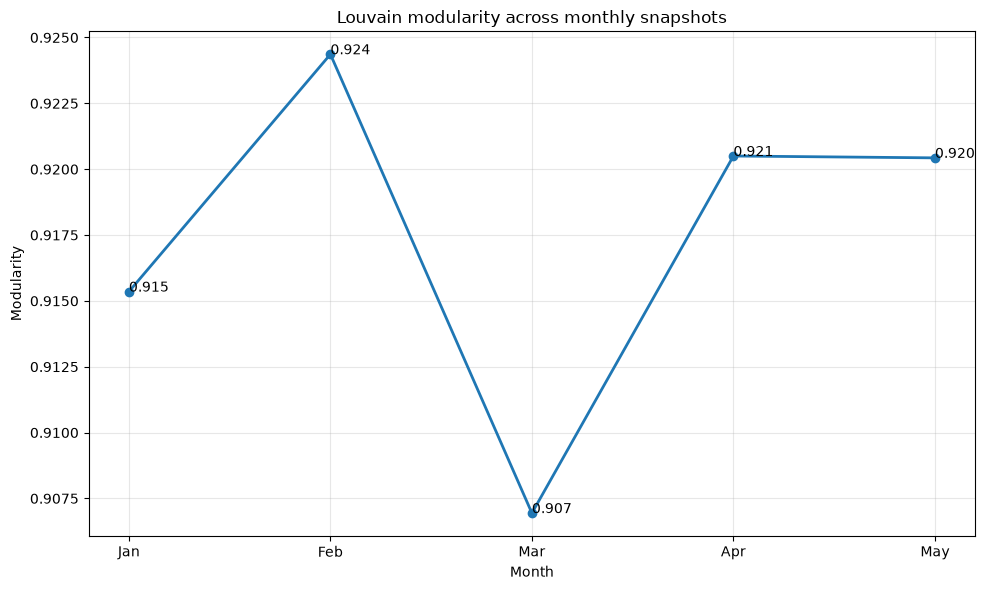

In [29]:
plt.figure(figsize=(10,6))

plt.plot(
    louvain_df["month"],
    louvain_df["modularity"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    louvain_df["month"],
    louvain_df["modularity"]
):
    plt.annotate(
        f"{y:.3f}",
        (x, y)
    )

plt.ylabel("Modularity")
plt.xlabel("Month")
plt.title("Louvain modularity across monthly snapshots")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Динамика размера LCC

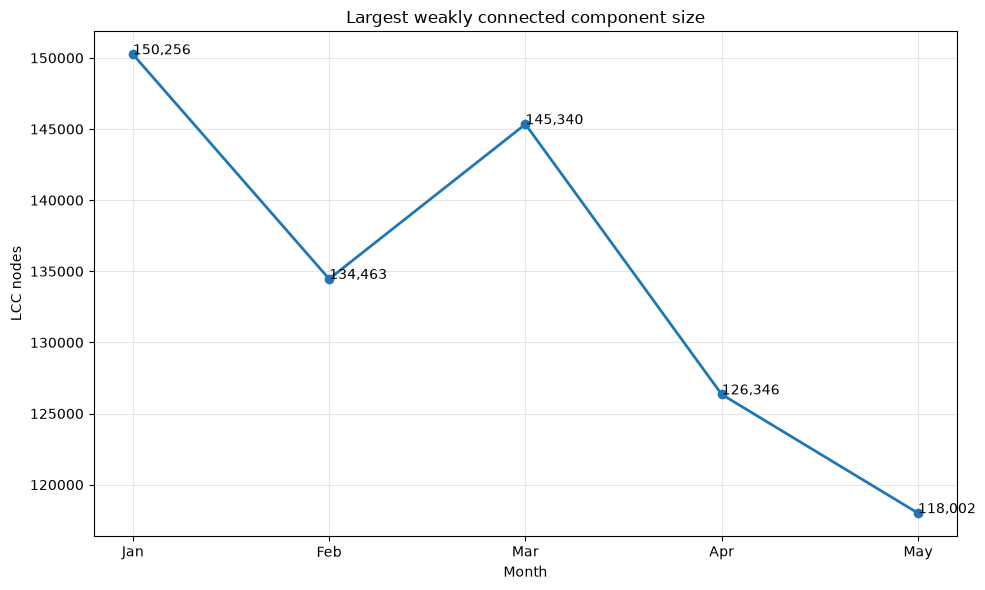

In [30]:
graph_df = (
    df
    .drop_duplicates("week")
    .sort_values("month_num")
)

plt.figure(figsize=(10,6))

plt.plot(
    graph_df["month"],
    graph_df["lcc_nodes"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    graph_df["month"],
    graph_df["lcc_nodes"]
):
    plt.annotate(
        f"{y:,}",
        (x, y)
    )

plt.ylabel("LCC nodes")
plt.xlabel("Month")

plt.title(
    "Largest weakly connected component size"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Динамика коэффициента Силуэта для Node2Vec

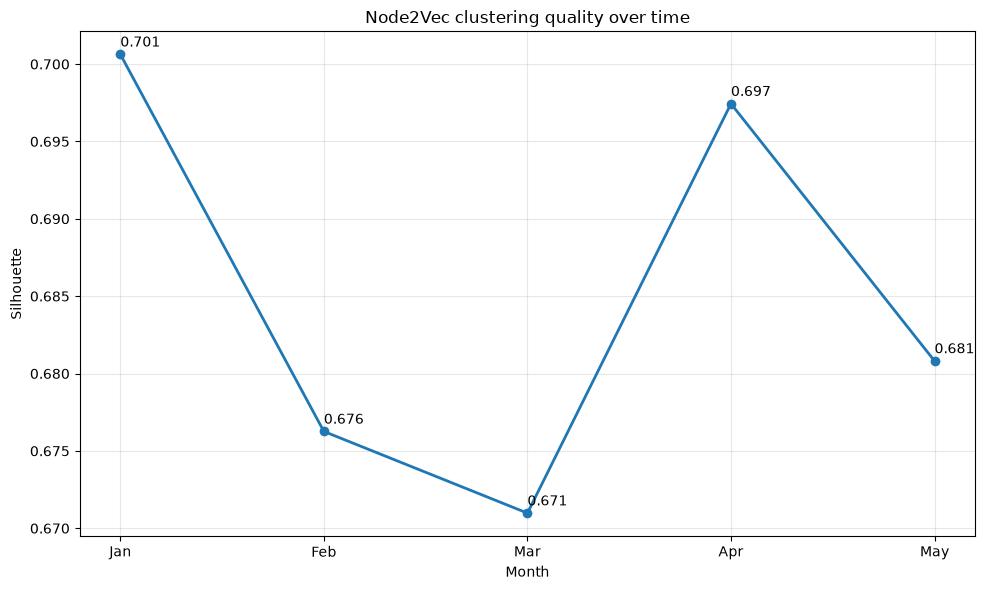

In [43]:
plt.figure(figsize=(10,6))

plt.plot(
    node2vec_df["month"],
    node2vec_df["silhouette"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    node2vec_df["month"],
    node2vec_df["silhouette"]
):
    plt.annotate(
        f"{y:.3f}",
        (x, y+0.0005)
    )

plt.ylabel("Silhouette")
plt.xlabel("Month")

plt.title(
    "Node2Vec clustering quality over time"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Динамика Noise Ratio для Node2Vec

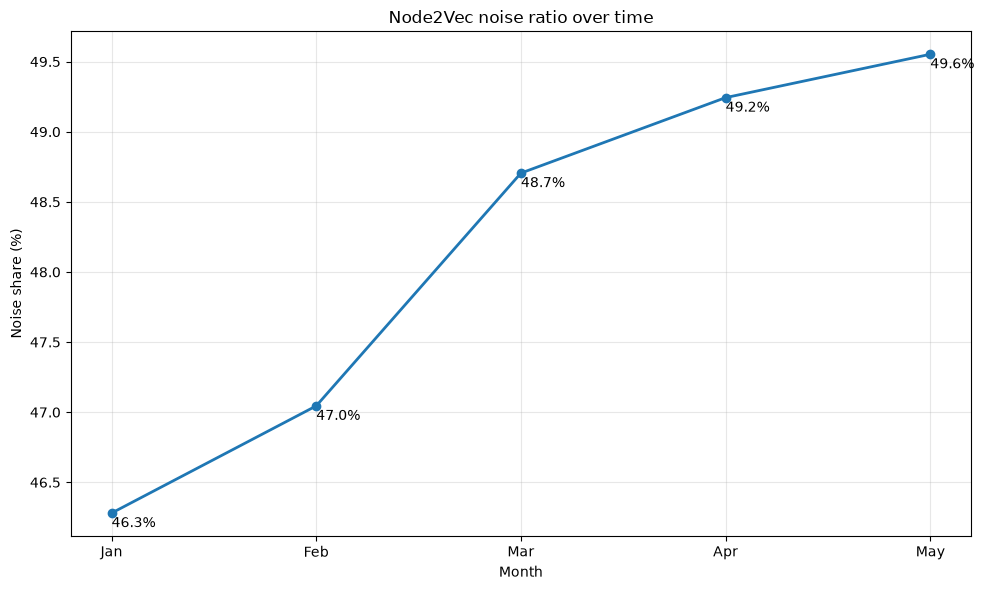

In [40]:
node2vec_df = node2vec_df.copy()

node2vec_df["noise_share"] = (
    node2vec_df["noise"]
    / node2vec_df["lcc_nodes"]
)

plt.figure(figsize=(10,6))

plt.plot(
    node2vec_df["month"],
    node2vec_df["noise_share"] * 100,
    marker="o",
    linewidth=2
)

for x, y in zip(
    node2vec_df["month"],
    node2vec_df["noise_share"] * 100
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y-0.1)
    )

plt.ylabel("Noise share (%)")
plt.xlabel("Month")

plt.title(
    "Node2Vec noise ratio over time"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Количество кластеров vs Размер графа

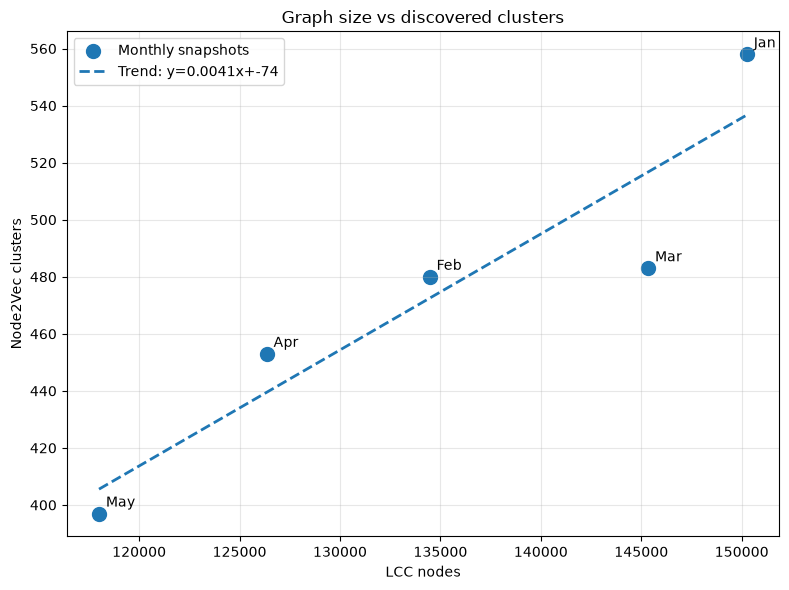

In [54]:
plt.figure(figsize=(8,6))

x = node2vec_df["lcc_nodes"].values
y = node2vec_df["clusters"].values

plt.scatter(
    x,
    y,
    s=100,
    label="Monthly snapshots"
)

# линия тренда
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_line,
    p(x_line),
    "--",
    linewidth=2,
    label=f"Trend: y={z[0]:.4f}x+{z[1]:.0f}"
)

for _, row in node2vec_df.iterrows():
    plt.annotate(
        row["month"],
        (
            row["lcc_nodes"],
            row["clusters"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("LCC nodes")
plt.ylabel("Node2Vec clusters")

plt.title(
    "Graph size vs discovered clusters"
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### Динамика метрик для Node2Vec

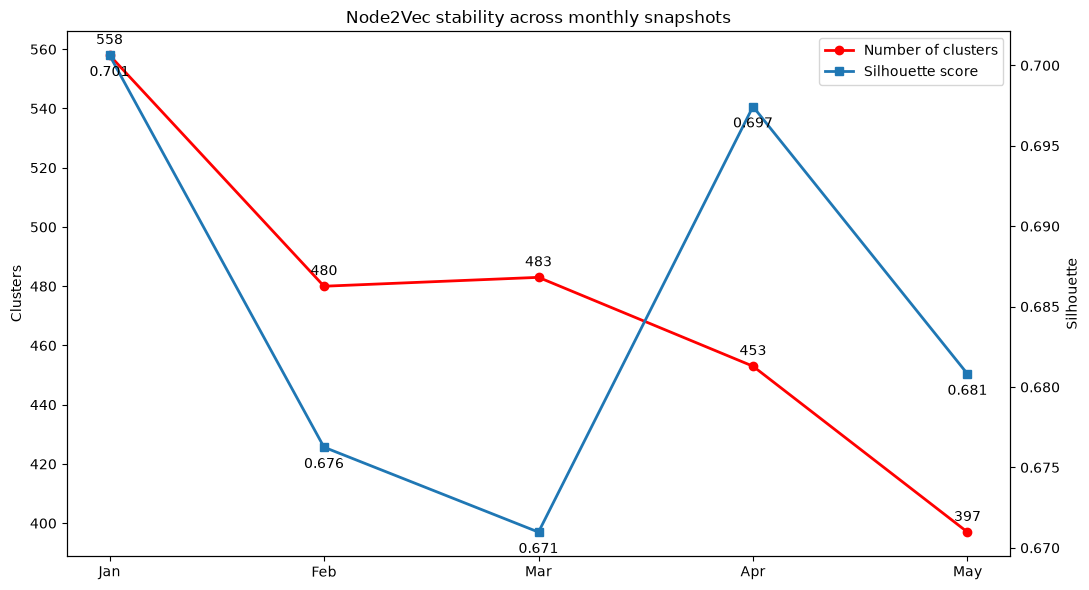

In [56]:
fig, ax1 = plt.subplots(figsize=(11,6))

line1 = ax1.plot(
    node2vec_df["month"],
    node2vec_df["clusters"],
    marker="o",
    linewidth=2,
    label="Number of clusters",
    color='red'
)

ax1.set_ylabel("Clusters")

for x, y in zip(
    node2vec_df["month"],
    node2vec_df["clusters"]
):
    ax1.annotate(
        str(y),
        (x, y),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )


ax2 = ax1.twinx()

line2 = ax2.plot(
    node2vec_df["month"],
    node2vec_df["silhouette"],
    marker="s",
    linewidth=2,
    label="Silhouette score"
)

ax2.set_ylabel("Silhouette")

# объединяем легенды с двух осей
lines = line1 + line2
labels = [l.get_label() for l in lines]

for x, y in zip(
    node2vec_df["month"],
    node2vec_df["silhouette"]
):
    ax2.annotate(
        f"{y:.3f}",
        (x, y),
        xytext=(0,-15),
        textcoords="offset points",
        ha="center"
    )

ax1.legend(
    lines,
    labels,
    loc="best"
)

plt.title(
    "Node2Vec stability across monthly snapshots"
)

plt.tight_layout()
plt.show()

### Сравнение методов

In [57]:
model_df = comparison_table.copy()

model_df["method_short"] = model_df["method"].replace({
    "Classical graph metrics": "Classical",
    "Node2Vec + HDBSCAN": "Node2Vec",
    "GraphSAGE + features": "GraphSAGE",
    "Structural GraphSAGE": "Struct. GraphSAGE"
})

model_df["noise_share"] = model_df["noise"] / G_main.number_of_nodes() * 100

#### Число кластеров

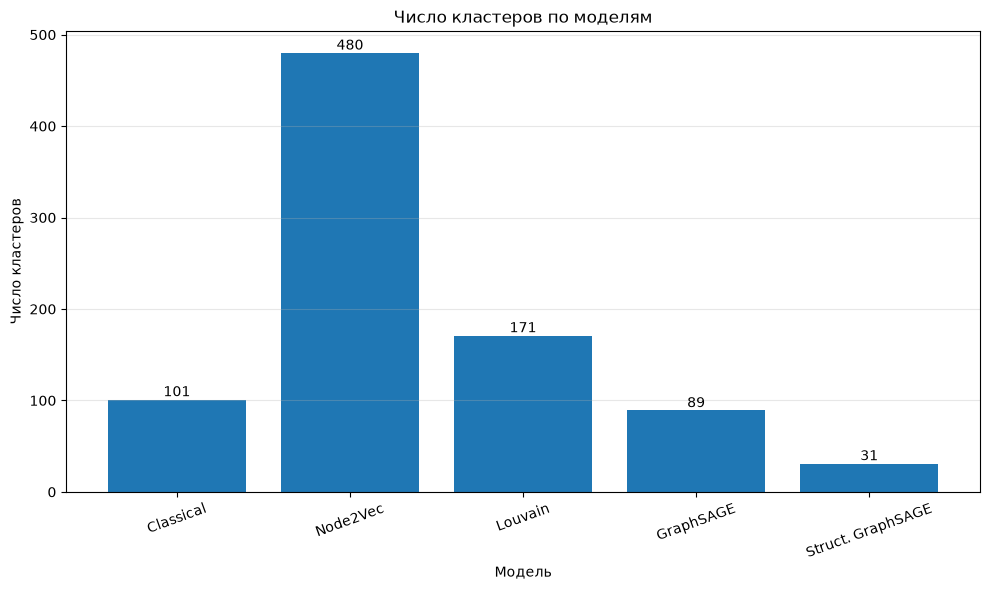

In [70]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_df["method_short"],
    model_df["clusters"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Число кластеров")
plt.xlabel("Модель")
plt.title("Число кластеров по моделям")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Доля шума

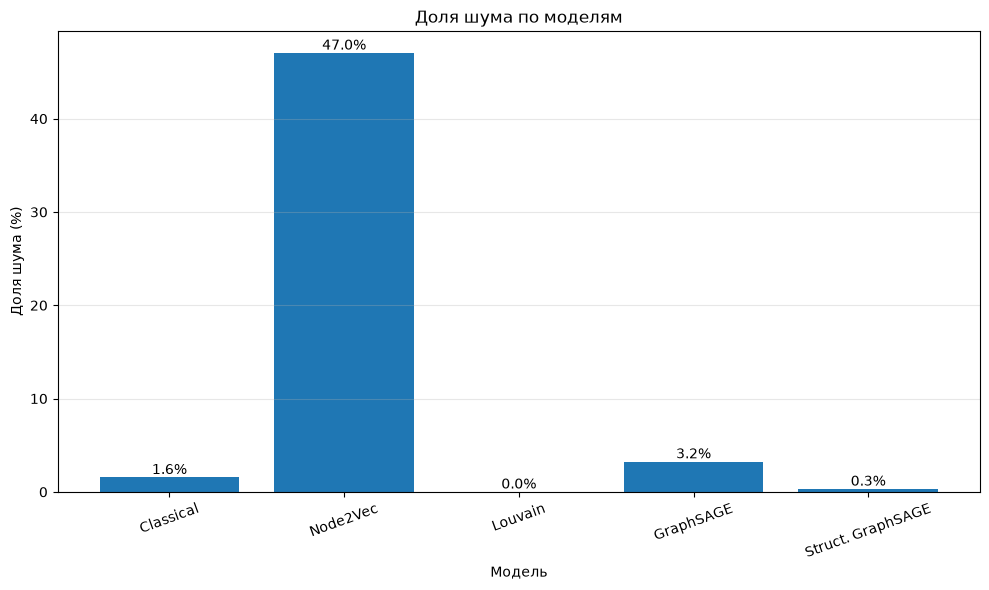

In [69]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_df["method_short"],
    model_df["noise_share"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylabel("Доля шума (%)")
plt.xlabel("Модель")
plt.title("Доля шума по моделям")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Коэффициент Силуэта

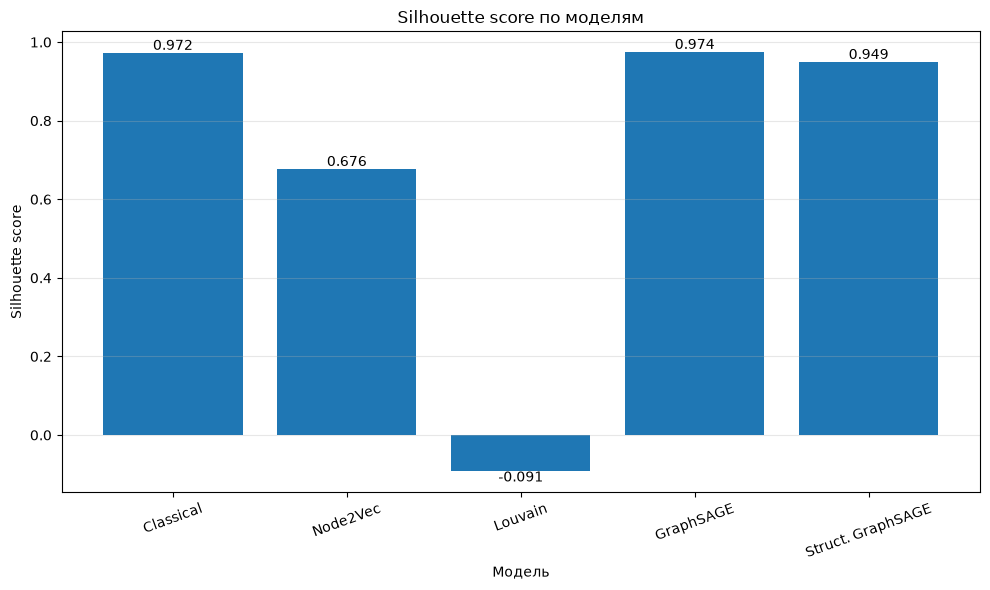

In [68]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_df["method_short"],
    model_df["silhouette"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom" if height >= 0 else "top"
    )

plt.ylabel("Silhouette score")
plt.xlabel("Модель")
plt.title("Silhouette score по моделям")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Davies-Bouldin index

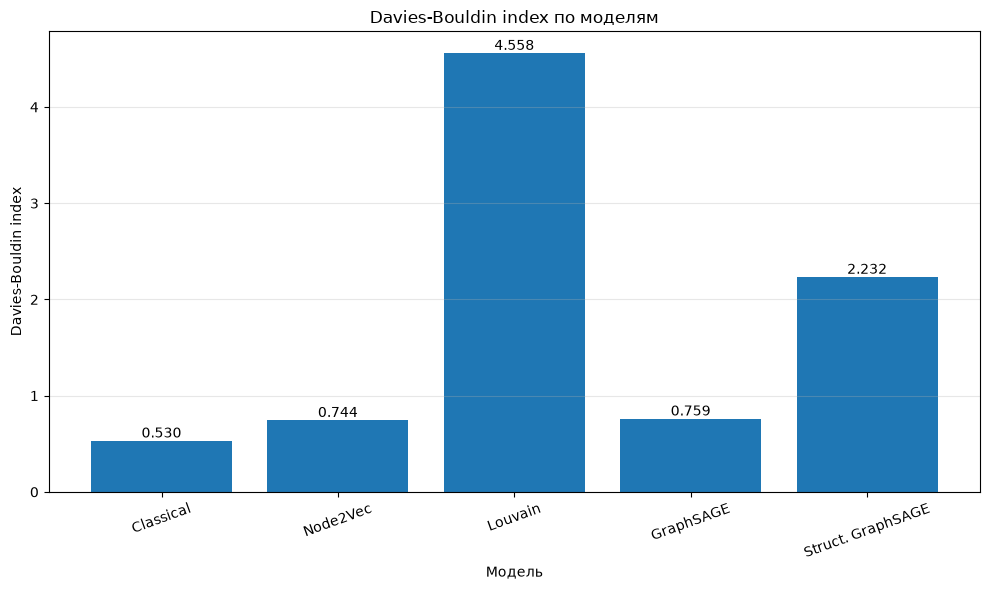

In [67]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_df["method_short"],
    model_df["davies_bouldin"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Davies-Bouldin index")
plt.xlabel("Модель")
plt.title("Davies-Bouldin index по моделям")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Доля точек внутри наибольшего кластера

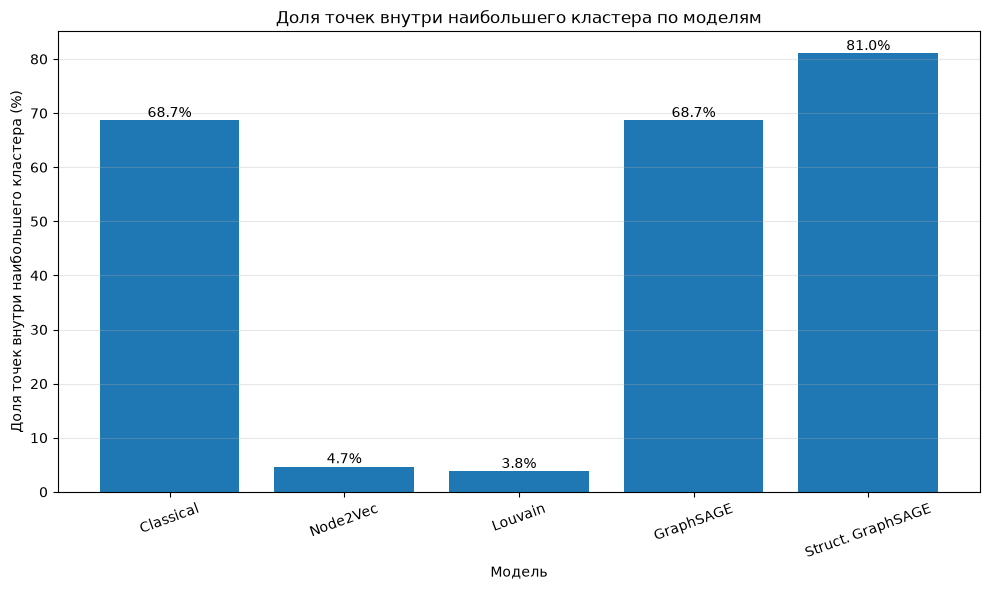

In [72]:
cluster_size_dict = {
    "Classical": pd.Series(baseline_labels).value_counts().max(),
    "Node2Vec": pd.Series(node2vec_labels).value_counts().drop(index=-1, errors="ignore").max(),
    "Louvain": pd.Series(louvain_labels).value_counts().max(),
    "GraphSAGE": pd.Series(graphsage_labels).value_counts().drop(index=-1, errors="ignore").max(),
    "Struct. GraphSAGE": pd.Series(struct_labels).value_counts().drop(index=-1, errors="ignore").max(),
}

largest_cluster_df = pd.DataFrame({
    "method": list(cluster_size_dict.keys()),
    "largest_cluster": list(cluster_size_dict.values())
})

largest_cluster_df["largest_cluster_share"] = (
    largest_cluster_df["largest_cluster"] / G_main.number_of_nodes() * 100
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    largest_cluster_df["method"],
    largest_cluster_df["largest_cluster_share"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylabel("Доля точек внутри наибольшего кластера (%)")
plt.xlabel("Модель")
plt.title("Доля точек внутри наибольшего кластера по моделям")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Интегральное сравнение методов

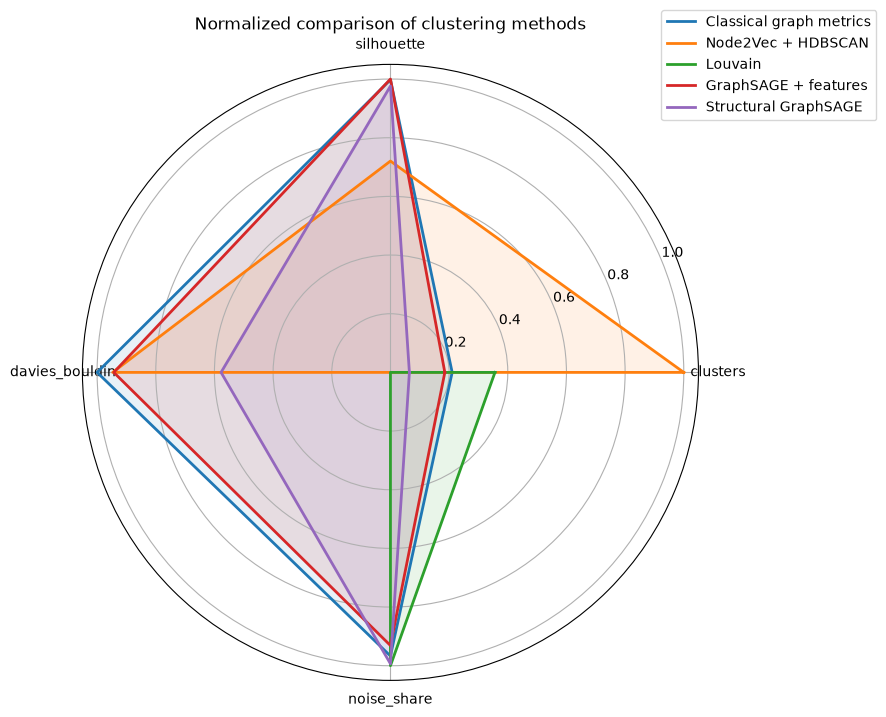

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics_df = comparison_table.copy()

metrics_df["noise_share"] = (
    metrics_df["noise"] / G_main.number_of_nodes()
)

metrics_df = metrics_df[
    [
        "method",
        "clusters",
        "silhouette",
        "davies_bouldin",
        "noise_share"
    ]
]

# нормализация
radar_df = metrics_df.copy()

radar_df["clusters"] = (
    radar_df["clusters"]
    / radar_df["clusters"].max()
)

radar_df["silhouette"] = (
    radar_df["silhouette"]
    - radar_df["silhouette"].min()
) / (
    radar_df["silhouette"].max()
    - radar_df["silhouette"].min()
)

# чем меньше DB тем лучше
radar_df["davies_bouldin"] = (
    radar_df["davies_bouldin"].max()
    - radar_df["davies_bouldin"]
) / (
    radar_df["davies_bouldin"].max()
    - radar_df["davies_bouldin"].min()
)

# чем меньше noise тем лучше
radar_df["noise_share"] = (
    radar_df["noise_share"].max()
    - radar_df["noise_share"]
) / (
    radar_df["noise_share"].max()
    - radar_df["noise_share"].min()
)

categories = [
    "clusters",
    "silhouette",
    "davies_bouldin",
    "noise_share"
]

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

for _, row in radar_df.iterrows():

    values = row[categories].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["method"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Normalized comparison of clustering methods")

plt.legend(
    bbox_to_anchor=(1.3,1.1)
)

plt.show()

### Транзакционная активность Bitcoin

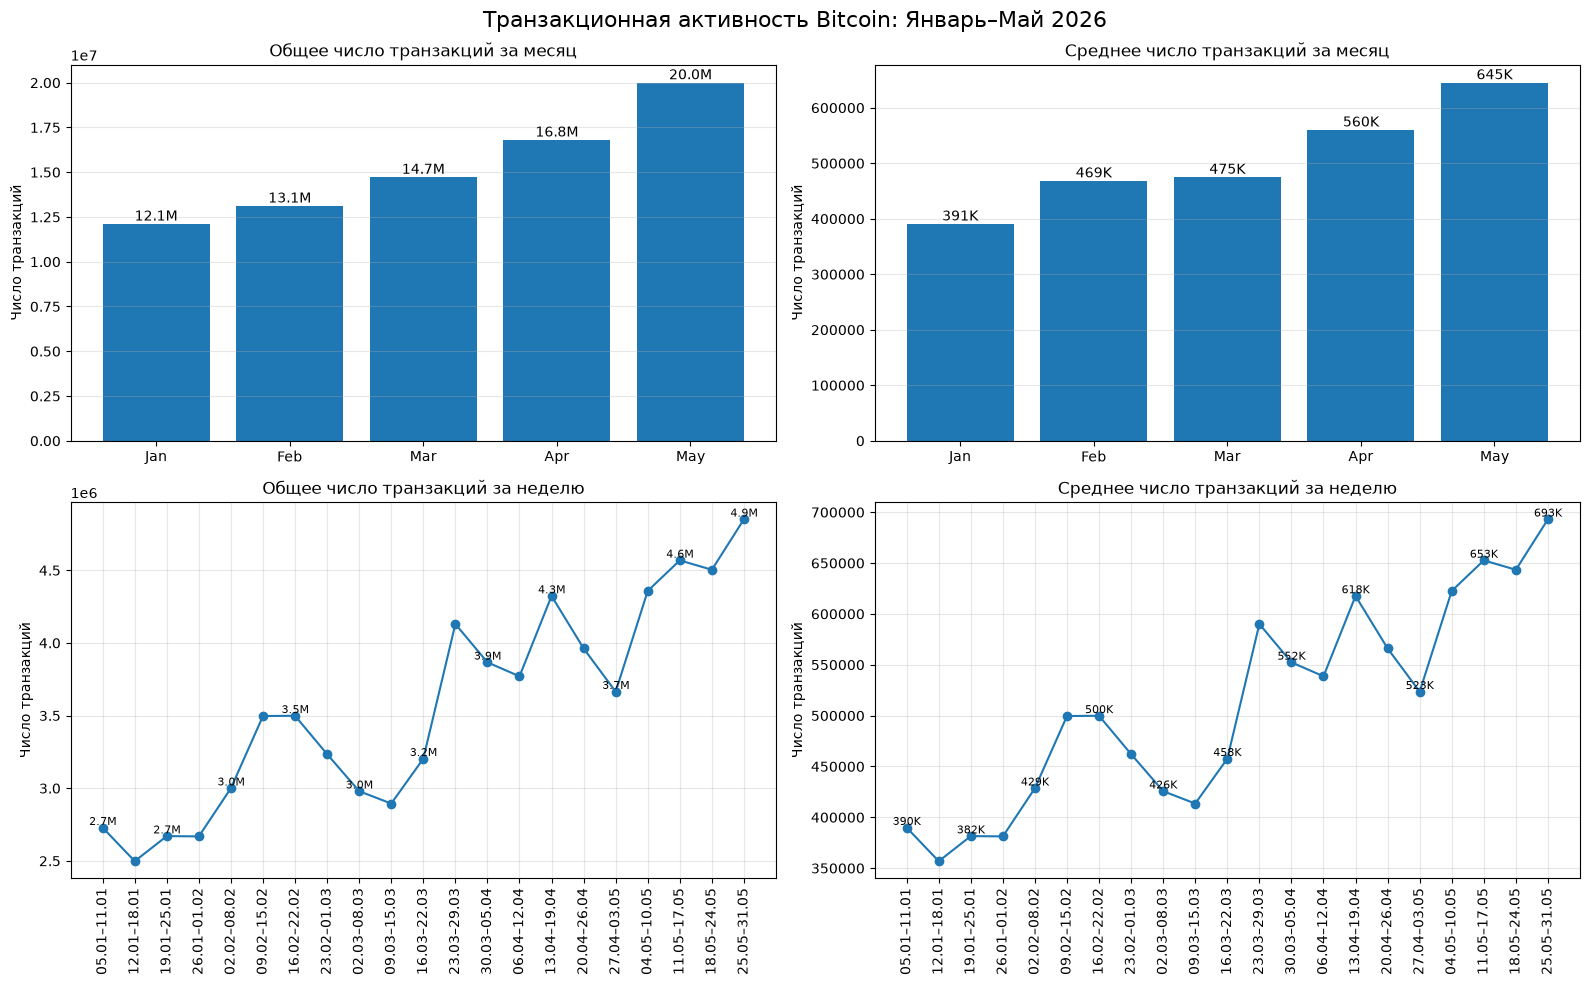

In [77]:
# =========================
# 1. Load data
# =========================

stats = pd.read_csv("data/staticstics.csv")

stats["day"] = pd.to_datetime(stats["day"])
stats = stats.sort_values("day")

# =========================
# 2. Monthly aggregation
# =========================

monthly_stats = (
    stats
    .set_index("day")
    .resample("ME")
    .agg(
        monthly_transactions=("transactions", "sum"),
        avg_daily_transactions_month=("transactions", "mean")
    )
    .reset_index()
)

monthly_stats["month"] = monthly_stats["day"].dt.strftime("%b")

# =========================
# 3. Weekly aggregation
# Monday-Sunday weeks
# =========================

weekly_stats = (
    stats
    .set_index("day")
    .resample("W-SUN")
    .agg(
        weekly_transactions=("transactions", "sum"),
        avg_daily_transactions_week=("transactions", "mean")
    )
    .reset_index()
)

weekly_stats["week_label"] = (
    (weekly_stats["day"] - pd.Timedelta(days=6)).dt.strftime("%d.%m")
    + "–"
    + weekly_stats["day"].dt.strftime("%d.%m")
)

# оставляем только полные недели внутри периода
weekly_stats = weekly_stats[
    (weekly_stats["day"] - pd.Timedelta(days=6) >= stats["day"].min()) &
    (weekly_stats["day"] <= stats["day"].max())
].copy()

# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly transaction count
axes[0, 0].bar(
    monthly_stats["month"],
    monthly_stats["monthly_transactions"]
)

axes[0, 0].set_title("Общее число транзакций за месяц")
axes[0, 0].set_ylabel("Число транзакций")
axes[0, 0].grid(axis="y", alpha=0.3)

for i, value in enumerate(monthly_stats["monthly_transactions"]):
    axes[0, 0].text(
        i,
        value,
        f"{value/1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

# 2. Average daily transactions by month
axes[0, 1].bar(
    monthly_stats["month"],
    monthly_stats["avg_daily_transactions_month"]
)

axes[0, 1].set_title("Среднее число транзакций за месяц")
axes[0, 1].set_ylabel("Число транзакций")
axes[0, 1].grid(axis="y", alpha=0.3)

for i, value in enumerate(monthly_stats["avg_daily_transactions_month"]):
    axes[0, 1].text(
        i,
        value,
        f"{value/1_000:.0f}K",
        ha="center",
        va="bottom"
    )

# 3. Weekly transaction count
axes[1, 0].plot(
    weekly_stats["week_label"],
    weekly_stats["weekly_transactions"],
    marker="o"
)

axes[1, 0].set_title("Общее число транзакций за неделю")
axes[1, 0].set_ylabel("Число транзакций")
axes[1, 0].tick_params(axis="x", rotation=90)
axes[1, 0].grid(alpha=0.3)

# подписи не для всех точек, чтобы не было перегруза
for i, value in enumerate(weekly_stats["weekly_transactions"]):
    if i % 2 == 0:
        axes[1, 0].text(
            i,
            value,
            f"{value/1_000_000:.1f}M",
            ha="center",
            va="bottom",
            fontsize=8
        )

# 4. Average daily transactions by week
axes[1, 1].plot(
    weekly_stats["week_label"],
    weekly_stats["avg_daily_transactions_week"],
    marker="o"
)

axes[1, 1].set_title("Среднее число транзакций за неделю")
axes[1, 1].set_ylabel("Число транзакций")
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].grid(alpha=0.3)

for i, value in enumerate(weekly_stats["avg_daily_transactions_week"]):
    if i % 2 == 0:
        axes[1, 1].text(
            i,
            value,
            f"{value/1_000:.0f}K",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.suptitle(
    "Транзакционная активность Bitcoin: Январь–Май 2026",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### Транзакционный граф

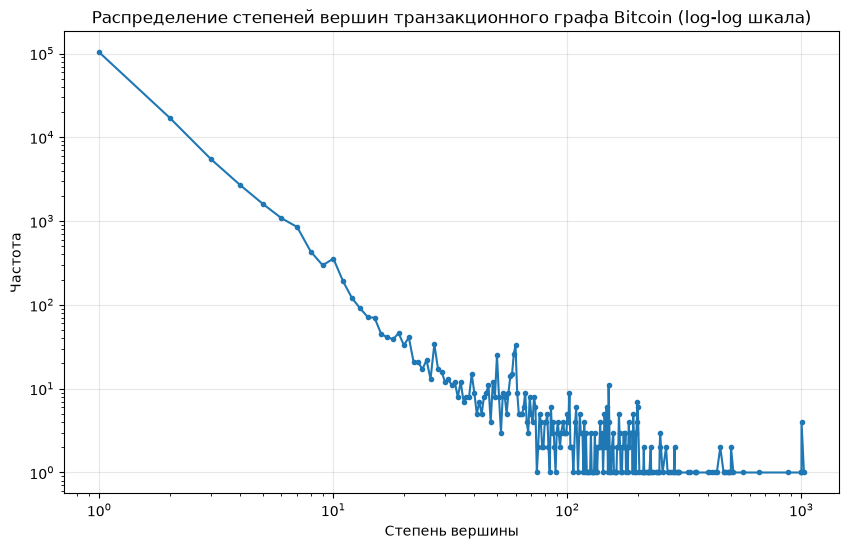

In [8]:
degrees = np.array(
    [d for _, d in G_main.degree()]
)

degree_counts = (
    pd.Series(degrees)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.loglog(
    degree_counts.index,
    degree_counts.values,
    marker="."
)

plt.xlabel("Степень вершины")
plt.ylabel("Частота")

plt.title(
    "Распределение степеней вершин транзакционного графа Bitcoin (log-log шкала)"
)

plt.grid(alpha=0.3)

plt.show()

### Сравнение размеров кластеров по моделям

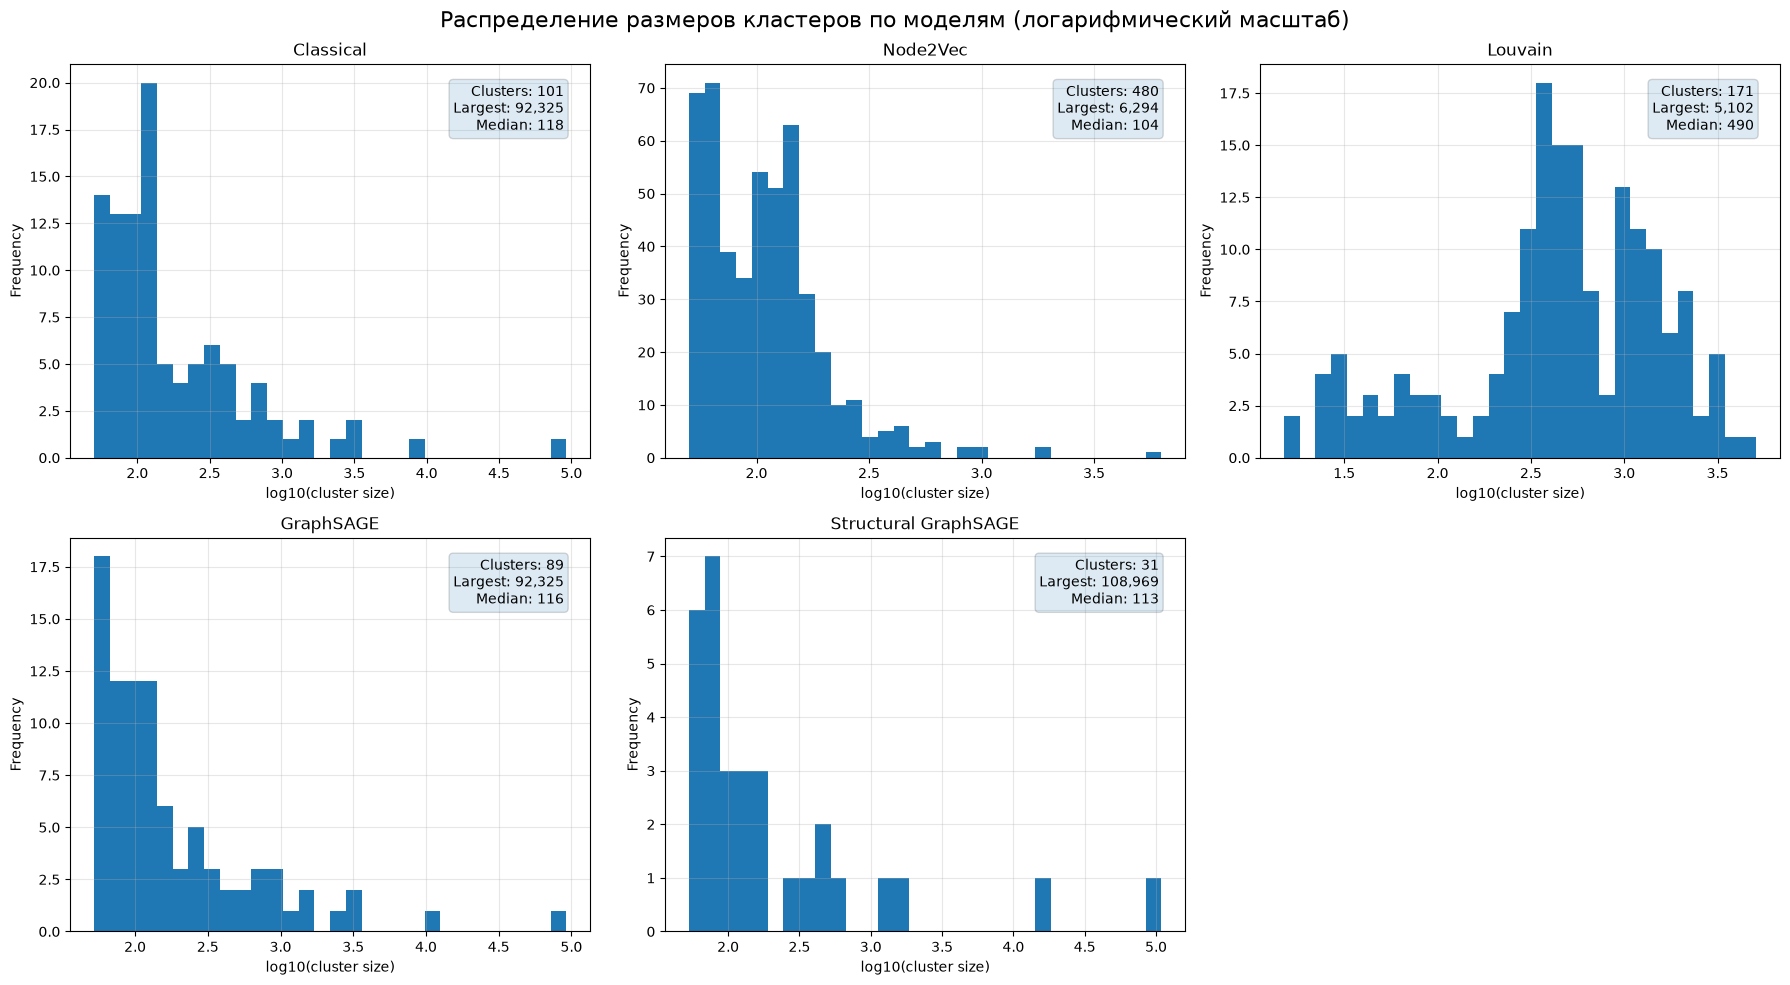

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster_labels_by_model = {
    "Classical": baseline_labels,
    "Node2Vec": node2vec_labels,
    "Louvain": louvain_labels,
    "GraphSAGE": graphsage_labels,
    "Structural GraphSAGE": struct_labels,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (model_name, labels) in zip(axes, cluster_labels_by_model.items()):
    sizes = pd.Series(labels).value_counts()
    sizes = sizes.drop(index=-1, errors="ignore")

    log_sizes = np.log10(sizes.values)

    ax.hist(
        log_sizes,
        bins=30
    )

    ax.set_title(model_name)
    ax.set_xlabel("log10(cluster size)")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

    ax.text(
        0.95,
        0.95,
        f"Clusters: {len(sizes)}\nLargest: {sizes.max():,}\nMedian: {sizes.median():.0f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

# убираем пустой шестой subplot
for i in range(len(cluster_labels_by_model), len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Распределение размеров кластеров по моделям (логарифмический масштаб)",
    fontsize=16
)

plt.tight_layout()
plt.show()